# Data Wrangling - Part 2: Transforming, Summarizing, Joining, and Reshaping Data

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

## Why these wrangling skills matter

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

---
## Set up your session

We will continue using the North Temperate Lakes Long-Term Ecological Research dataset used in the previous notebook.

In [2]:
# Packages
from pathlib import Path
import pandas as pd

In [5]:
# Paths
root_fldr = Path.cwd().parent.parent
raw_fldr = root_fldr / "data" / "raw"
processed_fldr = root_fldr / "data" / "processed"

In [6]:
# Data import
NTL_phys_data = pd.read_csv(
    raw_fldr / "NTL-LTER_Lake_ChemistryPhysics_Raw.csv",
    dtype={
        "lakeid": "category",
        "lakename": "category",
    },
    parse_dates=["sampledate"],
    date_format="%m/%d/%y"
)

NTL_phys_data.head()


,lakeid,lakename,year4,daynum,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,comments
0,L,Paul Lake,1984,148,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN
1,L,Paul Lake,1984,148,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN
2,L,Paul Lake,1984,148,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN
3,L,Paul Lake,1984,148,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN
4,L,Paul Lake,1984,148,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN


In [7]:
# Inspect columns, data types, and non-null counts
NTL_phys_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38614 entries, 0 to 38613
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   lakeid           38614 non-null  category      
 1   lakename         38614 non-null  category      
 2   year4            38614 non-null  int64         
 3   daynum           38614 non-null  int64         
 4   sampledate       38614 non-null  datetime64[us]
 5   depth            38614 non-null  float64       
 6   temperature_C    34756 non-null  float64       
 7   dissolvedOxygen  34575 non-null  float64       
 8   irradianceWater  24327 non-null  float64       
 9   irradianceDeck   23195 non-null  float64       
 10  comments         368 non-null    str           
dtypes: category(2), datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 2.7 MB


## 1. Selecting columns

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

In [8]:
# List all column names
NTL_phys_data.columns

Index(['lakeid', 'lakename', 'year4', 'daynum', 'sampledate', 'depth',
       'temperature_C', 'dissolvedOxygen', 'irradianceWater', 'irradianceDeck',
       'comments'],
      dtype='str')

In [ ]:
# Select one column, returning first few rows 
NTL_phys_data["lakename"].head()

0    Paul Lake
1    Paul Lake
2    Paul Lake
3    Paul Lake
4    Paul Lake
Name: lakename, dtype: category
Categories (9, str): ['Central Long Lake', 'Crampton Lake', 'East Long Lake', 'Hummingbird Lake', ..., 'Peter Lake', 'Tuesday Lake', 'Ward Lake', 'West Long Lake']

In [ ]:
# Select multiple columns, quick data frame 
core_cols = ["lakename", "sampledate", "depth", "temperature_C", "dissolvedOxygen"] #can also do do core_cols = [1,6] for quick syntax

lake_core = NTL_phys_data[core_cols]

lake_core.head()

,lakename,sampledate,depth,temperature_C,dissolvedOxygen
0,Paul Lake,1984-05-27,0.00,14.5,9.5
1,Paul Lake,1984-05-27,0.25,NaN,NaN
2,Paul Lake,1984-05-27,0.50,NaN,NaN
3,Paul Lake,1984-05-27,0.75,NaN,NaN
4,Paul Lake,1984-05-27,1.00,14.5,8.8


### Selecting columns with `.loc[]`

`.loc[]` can select rows and columns at the same time.

The general pattern is:

```python
df.loc[row_filter, column_selection]
```

The colon `:` means "all rows" or "all columns," depending on where it appears.

In [15]:
# Select all rows but only a few columns
lake_core_alt = NTL_phys_data.loc[1:10, core_cols]

lake_core_alt.head()

,lakename,sampledate,depth,temperature_C,dissolvedOxygen
1,Paul Lake,1984-05-27,0.25,NaN,NaN
2,Paul Lake,1984-05-27,0.50,NaN,NaN
3,Paul Lake,1984-05-27,0.75,NaN,NaN
4,Paul Lake,1984-05-27,1.00,14.5,8.8
5,Paul Lake,1984-05-27,1.50,NaN,NaN


In [16]:
# Select surface observations and a limited set of columns
surface_core = NTL_phys_data.loc[
    NTL_phys_data["depth"] == 0,
    core_cols
]

surface_core.head()

,lakename,sampledate,depth,temperature_C,dissolvedOxygen
0,Paul Lake,1984-05-27,0.0,14.5,9.5
17,Peter Lake,1984-05-28,0.0,14.8,9.2
39,Tuesday Lake,1984-05-29,0.0,15.0,9.5
55,Paul Lake,1984-06-03,0.0,18.8,8.0
71,Peter Lake,1984-06-04,0.0,18.8,9.0


### Exercise 1

Create a dataframe named `oxygen_data` that contains only these columns (in this order):

- `sampledate`
- `lakename`
- `depth`
- `dissolvedOxygen`

Then preview the first five rows.

In [ ]:
# Exercise 1 - Route #1
core_cols_oxygen = ['sampledate','lakename','depth','dissolvedOxygen']

oxygen_core = NTL_phys_data[core_cols_oxygen]

oxygen_core.head()

#Route 2 using Loc
oxygen_data = NTL_phys_data.loc[:,['sampledate','lakename','depth','dissolvedOxygen']]
oxygen_data.head(10)

,sampledate,lakename,depth,dissolvedOxygen
0,1984-05-27,Paul Lake,0.00,9.5
1,1984-05-27,Paul Lake,0.25,NaN
2,1984-05-27,Paul Lake,0.50,NaN
3,1984-05-27,Paul Lake,0.75,NaN
4,1984-05-27,Paul Lake,1.00,8.8
5,1984-05-27,Paul Lake,1.50,NaN
6,1984-05-27,Paul Lake,2.00,8.6
7,1984-05-27,Paul Lake,3.00,11.5
8,1984-05-27,Paul Lake,4.00,11.9
9,1984-05-27,Paul Lake,5.00,2.5


---
## 2. Renaming variables

Raw datasets often contain variable names that are abbreviated, inconsistent, or difficult to remember.

In pandas, we commonly rename columns with `.rename()`:

```python
df.rename(columns={"old_name": "new_name"})
```

By default, `.rename()` returns a modified copy. It does not permanently change the original dataframe unless you assign the result to a variable.

In [ ]:
# Rename selected columns for readability
lake_core_renamed = lake_core.rename(
    columns={
        "lakename": "lake_name", #existing column --> new column name 
        "sampledate": "sample_date", #make sure to avoid special characters and spaces in naming convention
        "dissolvedOxygen": "dissolved_oxygen",
    }
)

lake_core_renamed.head()

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen
0,Paul Lake,1984-05-27,0.00,14.5,9.5
1,Paul Lake,1984-05-27,0.25,NaN,NaN
2,Paul Lake,1984-05-27,0.50,NaN,NaN
3,Paul Lake,1984-05-27,0.75,NaN,NaN
4,Paul Lake,1984-05-27,1.00,14.5,8.8


### A note on naming conventions

For analysis workflows, consistent column names are more important than perfect column names.

A common Python-friendly convention is **snake_case**:

```text
lake_name
sample_date
dissolved_oxygen
```

Avoid spaces and special characters in column names when possible. They make code harder to write and can create problems in downstream tools.

In [21]:
# Compare original and renamed columns
print("Original columns:")
print(list(lake_core.columns))

print("\nRenamed columns:")
print(list(lake_core_renamed.columns))

Original columns:
['lakename', 'sampledate', 'depth', 'temperature_C', 'dissolvedOxygen']

Renamed columns:
['lake_name', 'sample_date', 'depth', 'temperature_C', 'dissolved_oxygen']


### Exercise 2

Create a renamed version of `oxygen_data` with the following column names:

- `lake_name`
- `sample_date`
- `depth_m`
- `dissolved_oxygen_mg_L`

Save the result as `oxygen_data_renamed`.

In [22]:
# Exercise 2
oxygen_data_renamed = oxygen_data.rename(
    columns={
        'lakename': 'lake_name',
        'sampledate':'sample_date',
        'dissolvedOxygen': 'dissolved_oxygen_mg_L',
        'depth':'depth_m'
    }
)

oxygen_data_renamed.head()


,sample_date,lake_name,depth_m,dissolved_oxygen_mg_L
0,1984-05-27,Paul Lake,0.00,9.5
1,1984-05-27,Paul Lake,0.25,NaN
2,1984-05-27,Paul Lake,0.50,NaN
3,1984-05-27,Paul Lake,0.75,NaN
4,1984-05-27,Paul Lake,1.00,8.8


## 3. Creating new variables

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

In [ ]:
# Create a copy before adding new variables
lake_features = lake_core_renamed.copy() #copy creates that new dataframe and just gives you a new space 

# Extract date components
lake_features["year"] = lake_features["sample_date"].dt.year
lake_features["month"] = lake_features["sample_date"].dt.month

lake_features.head()

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month
0,Paul Lake,1984-05-27,0.00,14.5,9.5,1984,5
1,Paul Lake,1984-05-27,0.25,NaN,NaN,1984,5
2,Paul Lake,1984-05-27,0.50,NaN,NaN,1984,5
3,Paul Lake,1984-05-27,0.75,NaN,NaN,1984,5
4,Paul Lake,1984-05-27,1.00,14.5,8.8,1984,5


In [ ]:
# Create a categorical variable from a numeric condition
lake_features["depth_zone"] = "below_surface" #every row get's a depth zone as label to begin with as below_surface
lake_features.loc[lake_features["depth"] == 0, "depth_zone"] = "surface" #then changes it to 0 if it's surface through loc function

lake_features[["lake_name", "sample_date", "depth", "depth_zone"]].head(10)

,lake_name,sample_date,depth,depth_zone
0,Paul Lake,1984-05-27,0.00,surface
1,Paul Lake,1984-05-27,0.25,below_surface
2,Paul Lake,1984-05-27,0.50,below_surface
3,Paul Lake,1984-05-27,0.75,below_surface
4,Paul Lake,1984-05-27,1.00,below_surface
5,Paul Lake,1984-05-27,1.50,below_surface
6,Paul Lake,1984-05-27,2.00,below_surface
7,Paul Lake,1984-05-27,3.00,below_surface
8,Paul Lake,1984-05-27,4.00,below_surface
9,Paul Lake,1984-05-27,5.00,below_surface


### Creating variables with `.assign()`

`.assign()` is useful in method chains because it returns a modified dataframe without changing the original object.

In [ ]:
# Create variables using assign()
lake_features_chained = ( #new dataframe
    lake_core_renamed #referenced data farme 
    .assign(
        year=lambda df: df["sample_date"].dt.year, #check for year column and then creates it for year 
        month=lambda df: df["sample_date"].dt.month, #then uses the previous value to choose month 
        is_surface=lambda df: df["depth"] == 0 #finally calculates depth to see if the depth is is surface or not by checking depth 
    )
)

lake_features_chained.head()

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,is_surface
0,Paul Lake,1984-05-27,0.00,14.5,9.5,1984,5,True
1,Paul Lake,1984-05-27,0.25,NaN,NaN,1984,5,False
2,Paul Lake,1984-05-27,0.50,NaN,NaN,1984,5,False
3,Paul Lake,1984-05-27,0.75,NaN,NaN,1984,5,False
4,Paul Lake,1984-05-27,1.00,14.5,8.8,1984,5,False


### Exercise 3

Starting from `lake_features`, create a new column named `season` using the month value.

Use this simple classification:

- December, January, February: `winter`
- March, April, May: `spring`
- June, July, August: `summer`
- September, October, November: `fall`

Hint: one approach is to create a dictionary that maps month numbers to season names, then use `.map()`.

In [ ]:
# Exercise 3

---
## 4. Sorting records

Sorting records helps us inspect data in a meaningful order.

The main pandas function is `.sort_values()`.

```python
df.sort_values("column_name")
```

Use `ascending=False` to sort from largest to smallest.

In [27]:
# Sort by date
lake_features.sort_values("sample_date").head()

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,depth_zone
0,Paul Lake,1984-05-27,0.0,14.5,9.5,1984,5,surface
16,Paul Lake,1984-05-27,12.0,4.5,0.3,1984,5,below_surface
15,Paul Lake,1984-05-27,11.0,4.5,0.3,1984,5,below_surface
14,Paul Lake,1984-05-27,10.0,4.5,0.3,1984,5,below_surface
12,Paul Lake,1984-05-27,8.0,4.5,0.3,1984,5,below_surface


In [ ]:
# Sort by dissolved oxygen from highest to lowest
lake_features.sort_values("dissolved_oxygen", ascending=False).head() #ascending = False is highest to lowest, the default will be ascending = True

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,depth_zone
25220,Tuesday Lake,2002-08-20,2.0,20.2,802.0,2002,8,below_surface
36195,Tuesday Lake,2014-07-09,1.5,20.7,703.0,2014,7,below_surface
5263,Paul Lake,1988-07-25,0.5,23.4,650.0,1988,7,below_surface
3724,Paul Lake,1987-07-26,0.5,23.4,650.0,1987,7,below_surface
36586,Peter Lake,2014-08-25,0.0,22.1,83.0,2014,8,surface


In [29]:
# Sort by multiple columns
lake_features.sort_values(["lake_name", "sample_date", "depth"]).head(10)

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,depth_zone
10203,Central Long Lake,1992-05-22,0.00,21.0,7.6,1992,5,surface
10204,Central Long Lake,1992-05-22,0.25,NaN,NaN,1992,5,below_surface
10205,Central Long Lake,1992-05-22,0.50,21.0,7.5,1992,5,below_surface
10206,Central Long Lake,1992-05-22,0.75,NaN,NaN,1992,5,below_surface
10207,Central Long Lake,1992-05-22,1.00,20.5,7.7,1992,5,below_surface
10208,Central Long Lake,1992-05-22,1.50,17.8,8.4,1992,5,below_surface
10209,Central Long Lake,1992-05-22,2.00,14.8,9.1,1992,5,below_surface
10210,Central Long Lake,1992-05-22,2.50,11.7,9.2,1992,5,below_surface
10211,Central Long Lake,1992-05-22,3.00,9.2,3.8,1992,5,below_surface
10212,Central Long Lake,1992-05-22,3.50,7.7,0.7,1992,5,below_surface


### Exercise 4

Create a dataframe named `deepest_records` that sorts the data from greatest depth to shallowest depth.

Display the columns `lake_name`, `sample_date`, `depth`, `temperature`, and `dissolved_oxygen` for the first 10 records.

In [32]:
# Exercise 4

deepest_records = lake_features.sort_values(["lake_name", "sample_date", "depth",'temperature_C','dissolved_oxygen'])

deepest_records.head(10)

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,depth_zone
10203,Central Long Lake,1992-05-22,0.00,21.0,7.6,1992,5,surface
10204,Central Long Lake,1992-05-22,0.25,NaN,NaN,1992,5,below_surface
10205,Central Long Lake,1992-05-22,0.50,21.0,7.5,1992,5,below_surface
10206,Central Long Lake,1992-05-22,0.75,NaN,NaN,1992,5,below_surface
10207,Central Long Lake,1992-05-22,1.00,20.5,7.7,1992,5,below_surface
10208,Central Long Lake,1992-05-22,1.50,17.8,8.4,1992,5,below_surface
10209,Central Long Lake,1992-05-22,2.00,14.8,9.1,1992,5,below_surface
10210,Central Long Lake,1992-05-22,2.50,11.7,9.2,1992,5,below_surface
10211,Central Long Lake,1992-05-22,3.00,9.2,3.8,1992,5,below_surface
10212,Central Long Lake,1992-05-22,3.50,7.7,0.7,1992,5,below_surface


## 5. Grouped summaries

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

<Axes: ylabel='lake_name'>

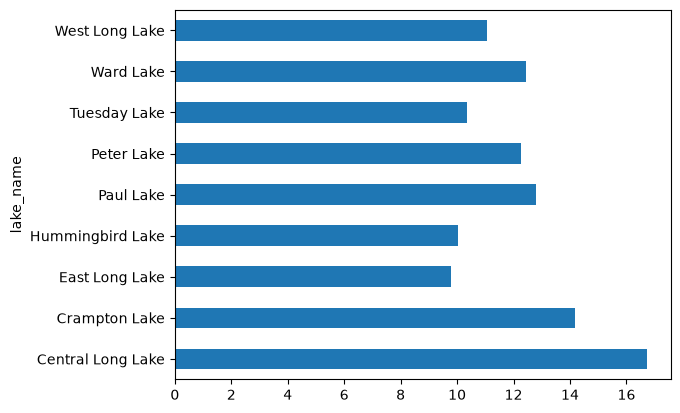

In [ ]:
# Average temperature by lake
lake_features.groupby("lake_name")["temperature_C"].mean() #can add .plot.barh() for quick and easy plot as well 

In [35]:
# Count observations by lake
lake_features.groupby("lake_name")["temperature_C"].count()

lake_name
Central Long Lake      443
Crampton Lake         1108
East Long Lake        3550
Hummingbird Lake       378
Paul Lake             9253
Peter Lake           10189
Tuesday Lake          5503
Ward Lake              527
West Long Lake        3805
Name: temperature_C, dtype: int64

### Named aggregations

For more organized output, use `.agg()` with named aggregations.

This creates a dataframe with clear column names.

In [39]:
# Summarize several variables by lake
lake_summary = (
    lake_features
    .groupby("lake_name")
    .agg( #enables multiple aggregate functions
        n_records=("temperature_C", "count"),
        first_sample=("sample_date", "min"),
        last_sample=("sample_date", "max"),
        max_depth=("depth", "max"),
        mean_depth=('depth','mean'),
        mean_temperature=("temperature_C", "mean"),
        mean_dissolved_oxygen=("dissolved_oxygen", "mean")
    )
    .reset_index()
)

lake_summary

,lake_name,n_records,first_sample,last_sample,max_depth,mean_depth,mean_temperature,mean_dissolved_oxygen
0,Central Long Lake,443,1992-05-22,1995-09-01,5.0,1.786642,16.736343,5.642396
1,Crampton Lake,1108,1999-06-11,2007-10-02,18.0,5.395259,14.192058,7.095578
2,East Long Lake,3550,1989-05-26,2006-08-22,12.0,4.651344,9.779296,2.706620
3,Hummingbird Lake,378,1999-05-25,2002-08-22,8.0,2.761628,10.037831,1.620924
4,Paul Lake,9253,1984-05-27,2016-08-16,20.0,4.112717,12.792275,5.635018
5,Peter Lake,10189,1984-05-28,2016-08-15,17.0,4.634612,12.252557,6.254994
6,Tuesday Lake,5503,1984-05-29,2016-08-17,16.0,4.339250,10.346702,3.740625
7,Ward Lake,527,2010-05-19,2012-08-28,9.0,3.079431,12.428083,3.320930
8,West Long Lake,3805,1989-05-27,2006-08-23,13.0,4.640282,11.058581,3.668663


### Grouping by more than one variable

You can group by multiple variables by passing a list of column names.

In [ ]:
# Create a surface-only dataset for seasonal summaries
surface_features = lake_features.loc[lake_features["depth"] == 0].copy()

# Add season using a month-to-season dictionary 
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "fall", 10: "fall", 11: "fall"
} #a way of assigning a month to a season or classification

surface_features["season"] = surface_features["month"].map(season_map) #mapping a dictionary onto existing values 

surface_season_summary = (
    surface_features
    .groupby(["lake_name", "season"])
    .agg(
        n_records=("temperature_C", "count"),
        mean_temperature=("temperature_C", "mean"),
        mean_dissolved_oxygen=("dissolved_oxygen", "mean")
    )
    #.reset_index() provides a different representation of data. See it flattened below 
)

surface_season_summary.head(12)

n_records  mean_temperature  mean_dissolved_oxygen
lake_name         season                                                    
Central Long Lake fall            5         18.020000               8.820000
                  spring          5         16.320000               8.580000
                  summer         38         20.934211               8.250000
Crampton Lake     fall            3         19.300000               8.500000
                  spring          6         13.583333              10.300000
                  summer         42         22.102381               8.252381
East Long Lake    fall           12         17.058333               8.091667
                  spring         22         16.063636               9.250000
                  summer        146         21.113699               7.893151
Hummingbird Lake  spring          3         14.166667               8.500000
                  summer         26         21.261538               6.673077
Paul Lake         fall           27         17.170370               7.859259

In [42]:
surface_season_summary = (
    surface_features
    .groupby(["lake_name", "season"])
    .agg(
        n_records=("temperature_C", "count"),
        mean_temperature=("temperature_C", "mean"),
        mean_dissolved_oxygen=("dissolved_oxygen", "mean")
    )
    .reset_index()
)

surface_season_summary.head(12)

,lake_name,season,n_records,mean_temperature,mean_dissolved_oxygen
0,Central Long Lake,fall,5,18.020000,8.820000
1,Central Long Lake,spring,5,16.320000,8.580000
2,Central Long Lake,summer,38,20.934211,8.250000
3,Crampton Lake,fall,3,19.300000,8.500000
4,Crampton Lake,spring,6,13.583333,10.300000
5,Crampton Lake,summer,42,22.102381,8.252381
6,East Long Lake,fall,12,17.058333,8.091667
7,East Long Lake,spring,22,16.063636,9.250000
8,East Long Lake,summer,146,21.113699,7.893151
9,Hummingbird Lake,spring,3,14.166667,8.500000


### Exercise 5

Create a grouped summary named `depth_zone_summary` that reports, for each `lake_name` and `depth_zone`:

- number of records
- mean temperature
- mean dissolved oxygen

Reset the index so the result is a regular dataframe.

In [ ]:
# Exercise 5

## 6. Joining datasets

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.

In [ ]:
# Create a small lake metadata table for demonstration. Making it up from scratch 
lake_metadata = pd.DataFrame({
    "lake_name": ["Allequash Lake", "Big Muskellunge Lake", "Crystal Lake", "Peter Lake", "Paul Lake", "Tuesday Lake", "Trout Lake"],
    "lake_group": ["reference", "reference", "reference", "experimental", "experimental", "experimental", "reference"],
    "landscape_position": ["upper", "lower", "upper", "upper", "upper", "upper", "lower"],
    "example_watershed_area_ha": [52.0, 98.0, 81.0, 14.0, 17.0, 11.0, 260.0]
})

lake_metadata

,lake_name,lake_group,landscape_position,example_watershed_area_ha
0,Allequash Lake,reference,upper,52.0
1,Big Muskellunge Lake,reference,lower,98.0
2,Crystal Lake,reference,upper,81.0
3,Peter Lake,experimental,upper,14.0
4,Paul Lake,experimental,upper,17.0
5,Tuesday Lake,experimental,upper,11.0
6,Trout Lake,reference,lower,260.0


In [ ]:
# Left join: keep all rows in lake_summary and add matching metadata
lake_summary_with_metadata = pd.merge(
    left = lake_summary,
    right = lake_metadata,
    on="lake_name",
    how="left" #can also do inner when records where can be combined. Can also do #outer which adds it on the outside 
)

lake_summary_with_metadata.head()

,lake_name,n_records,first_sample,last_sample,max_depth,mean_depth,mean_temperature,mean_dissolved_oxygen,lake_group,landscape_position,example_watershed_area_ha
0,Central Long Lake,443,1992-05-22,1995-09-01,5.0,1.786642,16.736343,5.642396,NaN,NaN,NaN
1,Crampton Lake,1108,1999-06-11,2007-10-02,18.0,5.395259,14.192058,7.095578,NaN,NaN,NaN
2,East Long Lake,3550,1989-05-26,2006-08-22,12.0,4.651344,9.779296,2.706620,NaN,NaN,NaN
3,Hummingbird Lake,378,1999-05-25,2002-08-22,8.0,2.761628,10.037831,1.620924,NaN,NaN,NaN
4,Paul Lake,9253,1984-05-27,2016-08-16,20.0,4.112717,12.792275,5.635018,experimental,upper,17.0


### Checking joins

Always check a join. Common problems include:

- misspelled key values,
- unexpected duplicates,
- missing matches, and
- different capitalization or spacing.

One useful option is `indicator=True`, which adds a column showing whether each row matched both tables.

In [47]:
# Diagnose matches between summary and metadata
join_check = pd.merge(
    lake_summary,
    lake_metadata,
    on="lake_name",
    how="left",
    indicator=True
)

join_check["_merge"].value_counts()

_merge
left_only     6
both          3
right_only    0
Name: count, dtype: int64

In [ ]:
# Show rows that did not match metadata
join_check.loc[join_check["_merge"] != "both", ["lake_name", "_merge"]]

### Exercise 6

Join `surface_season_summary` to `lake_metadata` using a left join.

Save the result as `surface_season_with_metadata`.

Then check how many records matched both datasets.

In [ ]:
# Exercise 6

---
## 7. Reshaping data between wide and long formats

Data can be stored in different shapes.

A **wide** dataset has multiple measurement variables stored in separate columns.

A **long** dataset stores measurement names in one column and measurement values in another column.

Long data is often easier for plotting, grouping, and modeling because each row represents one observation of one variable.

In [49]:
surface_features.head()

,lake_name,sample_date,depth,temperature_C,dissolved_oxygen,year,month,depth_zone,season
0,Paul Lake,1984-05-27,0.0,14.5,9.5,1984,5,surface,spring
17,Peter Lake,1984-05-28,0.0,14.8,9.2,1984,5,surface,spring
39,Tuesday Lake,1984-05-29,0.0,15.0,9.5,1984,5,surface,spring
55,Paul Lake,1984-06-03,0.0,18.8,8.0,1984,6,surface,summer
71,Peter Lake,1984-06-04,0.0,18.8,9.0,1984,6,surface,summer


In [60]:
# Start with a small wide dataset
surface_small_wide = surface_features.loc[
    :,
    ["lake_name", "sample_date", "temperature_C", "dissolved_oxygen"]
].head(10)

surface_small_wide

,lake_name,sample_date,temperature_C,dissolved_oxygen
0,Paul Lake,1984-05-27,14.5,9.5
17,Peter Lake,1984-05-28,14.8,9.2
39,Tuesday Lake,1984-05-29,15.0,9.5
55,Paul Lake,1984-06-03,18.8,8.0
71,Peter Lake,1984-06-04,18.8,9.0
89,Tuesday Lake,1984-06-05,21.0,8.4
107,Paul Lake,1984-06-10,19.6,8.5
124,Peter Lake,1984-06-11,19.8,8.9
142,Tuesday Lake,1984-06-12,20.4,8.9
161,Paul Lake,1984-06-17,21.0,7.3


### Wide to long with `melt()`

Use `pd.melt()` or `.melt()` to convert columns into rows.

Important arguments:

- `id_vars`: columns that identify each observation and should remain as identifiers
- `value_vars`: columns that contain measured values to reshape
- `var_name`: name of the new column containing variable names
- `value_name`: name of the new column containing values

In [61]:
# Convert from wide to long
surface_small_long = surface_small_wide.melt(
    id_vars=["lake_name", "sample_date"],
    value_vars=["temperature_C", "dissolved_oxygen"], #setting up values 
    var_name="measurement",
    value_name="value"
)

surface_small_long.head(15)

,lake_name,sample_date,measurement,value
0,Paul Lake,1984-05-27,temperature_C,14.5
1,Peter Lake,1984-05-28,temperature_C,14.8
2,Tuesday Lake,1984-05-29,temperature_C,15.0
3,Paul Lake,1984-06-03,temperature_C,18.8
4,Peter Lake,1984-06-04,temperature_C,18.8
5,Tuesday Lake,1984-06-05,temperature_C,21.0
6,Paul Lake,1984-06-10,temperature_C,19.6
7,Peter Lake,1984-06-11,temperature_C,19.8
8,Tuesday Lake,1984-06-12,temperature_C,20.4
9,Paul Lake,1984-06-17,temperature_C,21.0


### Long to wide with `pivot_table()`

Use `.pivot_table()` to convert long data back to wide form.

Important arguments:

- `index`: columns that identify rows
- `columns`: the column whose values should become new column names
- `values`: the column whose values should fill the table
- `aggfunc`: how to handle duplicate combinations

In [56]:
# Convert from long back to wide
surface_small_wide_again = (
    surface_small_long
    .pivot_table(
        index=["lake_name", "sample_date"],
        columns="measurement",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

# Remove the columns axis name created by pivot_table
surface_small_wide_again.columns.name = None

surface_small_wide_again.head()

,lake_name,sample_date,dissolved_oxygen,temperature_C
0,Paul Lake,1984-05-27,9.5,14.5
1,Paul Lake,1984-06-03,8.0,18.8
2,Paul Lake,1984-06-10,8.5,19.6
3,Paul Lake,1984-06-17,7.3,21.0
4,Peter Lake,1984-05-28,9.2,14.8


### Reshaping grouped summaries

Reshaping is especially useful after grouped summaries.

For example, suppose we want one row per lake and one column per season for mean surface temperature.

In [57]:
# Create a wide table of mean surface temperature by lake and season
season_temperature_wide = (
    surface_season_summary
    .pivot_table(
        index="lake_name",
        columns="season",
        values="mean_temperature"
    )
    .reset_index()
)

season_temperature_wide.columns.name = None

season_temperature_wide.head()

,lake_name,fall,spring,summer
0,Central Long Lake,18.020000,16.320000,20.934211
1,Crampton Lake,19.300000,13.583333,22.102381
2,East Long Lake,17.058333,16.063636,21.113699
3,Hummingbird Lake,NaN,14.166667,21.261538
4,Paul Lake,17.170370,16.546774,21.725747


In [58]:
# Convert that seasonal summary back to long format
season_temperature_long = season_temperature_wide.melt(
    id_vars="lake_name",
    var_name="season",
    value_name="mean_temperature"
)

season_temperature_long.head(12)

,lake_name,season,mean_temperature
0,Central Long Lake,fall,18.020000
1,Crampton Lake,fall,19.300000
2,East Long Lake,fall,17.058333
3,Hummingbird Lake,fall,NaN
4,Paul Lake,fall,17.170370
5,Peter Lake,fall,16.959375
6,Tuesday Lake,fall,16.576000
7,Ward Lake,fall,NaN
8,West Long Lake,fall,17.033333
9,Central Long Lake,spring,16.320000


### Exercise 7

Create a long version of `surface_season_summary` that keeps `lake_name`, `season`, and `n_records` as identifier columns, then reshapes these columns into a measurement/value pair:

- `mean_temperature`
- `mean_dissolved_oxygen`

Name the new columns `measurement` and `mean_value`.

In [ ]:
# Exercise 7

---
## 8. Pulling it together: an analysis-ready workflow

The following workflow demonstrates how several wrangling steps can be combined into one readable pipeline.

The goal is to create a lake-by-season summary of surface observations, joined to lake metadata, with clear variable names.

In [ ]:
analysis_ready_summary = (
    NTL_phys_data
    .rename(columns={
        "lakename": "lake_name",
        "sampledate": "sample_date",
        "dissolvedOxygen": "dissolved_oxygen"
    })
    .loc[lambda df: df["depth"] == 0]
    .assign(
        year=lambda df: df["sample_date"].dt.year, #creates year 
        month=lambda df: df["sample_date"].dt.month, #creates month 
        season=lambda df: df["month"].map(season_map) #mapping seasons 
    )
    .groupby(["lake_name", "season"]) #grouping 
    .agg(
        n_records=("temperature_C", "count"),
        mean_temperature=("temperature_C", "mean"),
        mean_dissolved_oxygen=("dissolved_oxygen", "mean")
    )
    .reset_index()
    .merge(lake_metadata, on="lake_name", how="left")
    .sort_values(["lake_name", "season"])
)

analysis_ready_summary.head(12)

,lake_name,season,n_records,mean_temperature,mean_dissolved_oxygen,lake_group,landscape_position,example_watershed_area_ha
0,Central Long Lake,fall,5,18.020000,8.820000,NaN,NaN,NaN
1,Central Long Lake,spring,5,16.320000,8.580000,NaN,NaN,NaN
2,Central Long Lake,summer,38,20.934211,8.250000,NaN,NaN,NaN
3,Crampton Lake,fall,3,19.300000,8.500000,NaN,NaN,NaN
4,Crampton Lake,spring,6,13.583333,10.300000,NaN,NaN,NaN
5,Crampton Lake,summer,42,22.102381,8.252381,NaN,NaN,NaN
6,East Long Lake,fall,12,17.058333,8.091667,NaN,NaN,NaN
7,East Long Lake,spring,22,16.063636,9.250000,NaN,NaN,NaN
8,East Long Lake,summer,146,21.113699,7.893151,NaN,NaN,NaN
9,Hummingbird Lake,spring,3,14.166667,8.500000,NaN,NaN,NaN


### Exporting a processed dataset

When you create a useful intermediate dataset, save it to the `data/processed/` folder rather than overwriting the raw data.

This keeps the workflow reproducible:

- raw data stays unchanged,
- processed data can be recreated from code,
- notebook outputs are easier to review.

In [ ]:
# Export the analysis-ready summary
analysis_ready_summary.to_csv(
    processed_fldr / "NTL_surface_season_summary.csv",
    index=False
)

## Capstone exercise

Create a processed dataset that meets the following specifications:

1. Use only observations from Peter, Paul, and Tuesday Lakes.
2. Use only surface observations.
3. Keep only these variables from the raw dataset:
   - lake name
   - sample date
   - depth
   - temperature
   - dissolved oxygen
4. Rename the variables using `snake_case` names.
5. Create `year`, `month`, and `season` columns.
6. Remove records with missing values in temperature or dissolved oxygen.
7. Summarize by lake and season.
8. Report:
   - number of records
   - mean temperature
   - mean dissolved oxygen
9. Join the result to `lake_metadata`.
10. Sort the result by lake name and season.

Save the final dataframe as `peter_paul_tuesday_summary`.

In [ ]:
# Capstone exercise

## Key takeaways

This section introduces the core concept. Focus on the examples below and experiment by modifying the code to reinforce your understanding.